         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_worst  smoothness

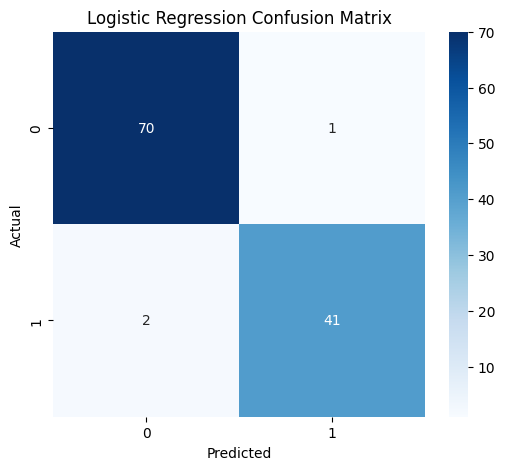

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ==========================
# 1. 读取数据
# ==========================

data = pd.read_csv('breast cancer.csv')

print(data.head())

# ==========================
# 2. 删除全空列
# ==========================

data = data.dropna(axis=1, how='all')

# ==========================
# 3. 删除无用列
# ==========================

if 'id' in data.columns:
    data.drop(['id'], axis=1, inplace=True)

# ==========================
# 4. 标签编码
# ==========================

encoder = LabelEncoder()

data['diagnosis'] = encoder.fit_transform(
    data['diagnosis']
)

# ==========================
# 5. 特征与标签
# ==========================

X = data.drop('diagnosis', axis=1)
y = data['diagnosis']

# ==========================
# 6. 转换数字类型
# ==========================

X = X.apply(pd.to_numeric, errors='coerce')

# ==========================
# 7. 填补空值
# ==========================

imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)

# ==========================
# 8. 标准化
# ==========================

scaler = StandardScaler()
X = scaler.fit_transform(X)

# ==========================
# 9. 划分数据集
# ==========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ==========================
# 10. 创建模型
# ==========================

model = LogisticRegression(max_iter=5000)

# ==========================
# 11. 记录训练时间
# ==========================

start_time = time.time()

model.fit(X_train, y_train)

end_time = time.time()

training_time = end_time - start_time

# ==========================
# 12. 预测
# ==========================

y_pred = model.predict(X_test)

# ==========================
# 13. 计算指标
# ==========================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

# ==========================
# 14. 输出结果
# ==========================

print("\n========== 模型评估结果 ==========")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")
print(f"训练时间   : {training_time:.6f} 秒")

# ==========================
# 15. 分类报告
# ==========================

print("\n========== Classification Report ==========\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=['Benign', 'Malignant']
    )
)

# ==========================
# 16. 混淆矩阵
# ==========================

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    'Logistic Regression Confusion Matrix'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()